# 1. Intro

1.1. Примеры применения машинного обучения в жизни (исключая примеры, приведенные в Главе 2 Readme): предсказание исхода политических выборов на основе некоторых данных о голосующих (отдельное голосование) или иных признаков (например, выборы во всех демократических странах в определенном году), предсказание успешности запуска космических ракет, предсказание количества успешных попаданий отдельных биатлонистов на Олимпийских играх, кластеризация посетителей магазина по траекториям продвижения по товарным рядам, установление потенциального KPI на ближайший год кандидата на руководящую должность на основе результатов набора тестирований. Во всех случаях, кроме четвертого, ML позволяет делать предсказания значений некоторой целевой переменной на основе известных значений признаков. В четвертом случае нет целевой переменной, но информация о кластерах ценна сама по себе и позволяет принимать некоторые решения на ее основе.

1.2.

1) Предсказание стоимости домов - регрессия (обучение с учителем);

2) возвращение клиентом долга по кредиту - классификация (бинарная, обучение с учителем);

3) необходимость принять препарат пациенту - классификация (бинарная, обучение с учителем);

4) выбор препарата для пациента из доступных - классификация (мультиклассовая, обучение с учителем);

5) выбор сегмента клиентов для показа рекламы - классификация (мультикласс, обучение с учителем), возможно, с предшествующей кластеризацией для выделения сегментов клиентов (обучение без учителя);

6) распознание дефектных товаров - если известны признаки дефектных товаров, классификация (бинарная, обучение с учителем), если неизвестны и мы считаем, что большинство товаров не дефективные - кластеризация (сведение к двум кластерам, обучение без учителя);

7) размещение товаров на полке в магазине - ассоциация (понять, какие продукты часто покупают вместе, обучение без учителя);

8) поиск сайтов по запросу - это задача ранжирования, можно обозначить ее как задачу регрессии (предсказание степени релевантности сайта с последующим ранжированием), либо как задачу бинарной классификации с сопоставлением запроса и сайтов (релевантен сайт запросу или нет) - обучение с учителем;

9) разбиение покупателей на сегменты для изучения их поведения - кластеризация (обучение без учителя);

10) распознание аномалий в траффике сайта - кластеризация (обучение без учителя). 

Мои примеры: 

а) первый - бинарная (если кандидата два или, например, есть две партии, если мы смотрим на уровне партий) или мультиклассовая классификация (обучение с учителем), если мы не подсчитываем голоса за некоторого кандидата в качестве целевой переменной;

б) успешность запуска космических ракет - классификация (обучение с учителем; бинарная или небинарная в зависимости от того, насколько детально мы хотим предсказывать запуск);

в) количество успешных попаданий биатлонистов - регрессия (обучение с учителем);

г) кластеризация посетителей магазина - собственно, кластеризация (обучение без учителя);

д) установление потенциального KPI на будущий год кандидата - регрессия (или классификация, если KPI можно закодировать в классы, причем мультиклассовая или multilabel в зависимости от того, как мы можем и хотим измерять KPI; обучение с учителем).

1.3. Multiclass-классификация - классификация, где значениями целевой переменной может становится более чем два класса, однако каждое наблюдение можно записать только в один класс. В multilabel-классификации каждое наблюдение можно записать сразу в несколько классов одновременно.

1.4. В целом, предсказание цен - проблема регрессии. Однако можно переквалифицировать ее в проблему в таковую классификации, если разбить интервалы цен на небольшое количество групп, тогда это будет проблема классификации.

# 2. Введение в анализ данных (Introduction to Data Analysis)

## 2.1. Импорт библиотек

In [113]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

## 2.2. Загрузка данных

In [114]:
df = pd.read_json('data/train.json')
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


## 2.3. Размер данных

In [115]:
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размер данных: 49352 строк, 15 столбцов


## 2.4. Список столбцов

In [116]:
print("Список столбцов:")
print(df.columns.tolist())

Список столбцов:
['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']


Целевой столбец — **price** (цена аренды квартиры в USD). Его мы и будем предсказывать.

## 2.4. Быстрый анализ данных

In [117]:
df.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


In [118]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [119]:
df.select_dtypes(include=[np.number]).corr()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


**Результаты анализа:**

**info()** показывает типы данных каждого столбца и количество ненулевых значений. Числовые столбцы: bathrooms, bedrooms, latitude, listing_id, longitude, price. Строковые/объектные: building_id, created, description, display_address, features, interest_level, manager_id, photos, street_address.

**describe()** дает статистические показатели (среднее, стандартное отклонение, минимальное значение, максимальное, квартили) для числовых столбцов датафрейма. Видно, что price имеет очень большой разброс (max значительно больше среднего), что указывает на наличие выбросов.

**corr()** показывает корреляцию между числовыми признаками. Наибольшая корреляция наблюдается между bathrooms и bedrooms (также между latitude и longitude, но это само собой очевидно).

**Пустых столбцов** (целиком состоящих из NaN) нет - все столбцы содержат данные.

## 2.6. Создание рабочего датафрейма с 4 столбцами

In [120]:
data = df[['bathrooms', 'bedrooms', 'interest_level', 'price']].copy()
data.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


# 3. Статистический анализ данных (Statistical Data Analysis)

## 3.3. Анализ целевой переменной

## 3.3.1. Гистограмма распределения price

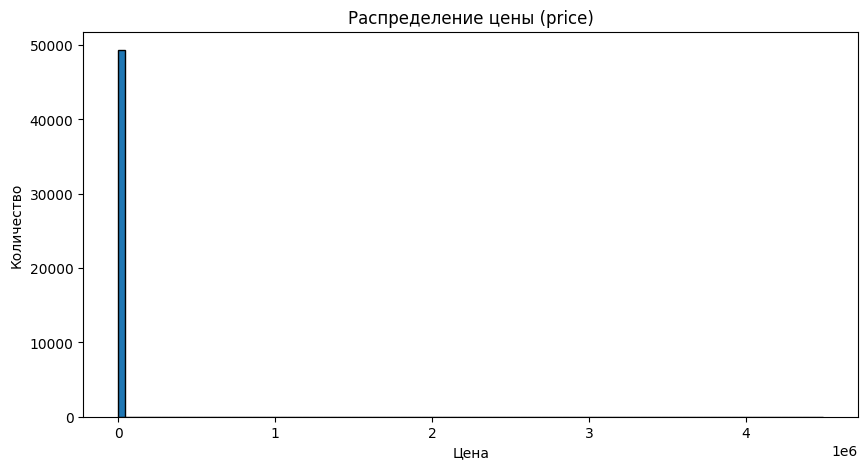

In [121]:
plt.figure(figsize=(10, 5))
plt.hist(data['price'], bins=100, edgecolor='black')
plt.title('Распределение цены (price)')
plt.xlabel('Цена')
plt.ylabel('Количество')

plt.show()

Распределение сильно скошено вправо (right-skew). Основная масса данных сконцентрирована в области низких цен, но есть, похоже, экстремальные выбросы с очень высокими значениями, из-за чего гистограмма «сжата» к левому краю (самих этих выбросов при это на графике не видно - их слишком мало, что не мешает им, впрочем, скашивать данные). Это затрудняет анализ, так что необходимо обработать выбросы.

## 3.3.2. Boxplot для price

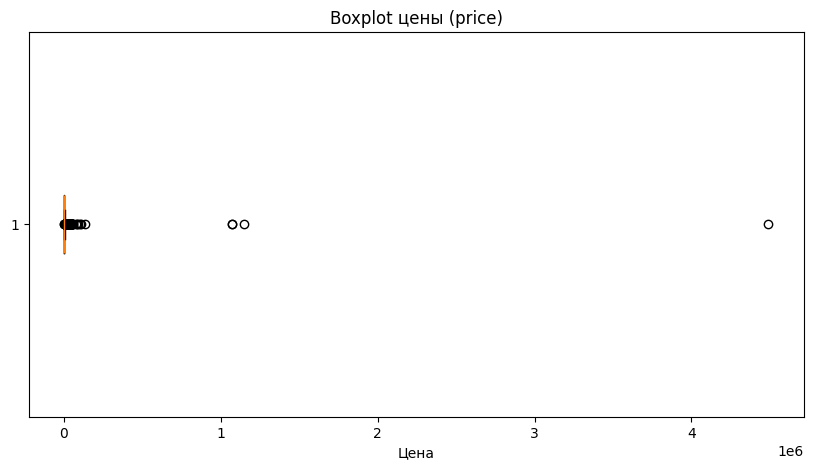

In [122]:
plt.figure(figsize=(10, 5))
plt.boxplot(data['price'], vert=False)
plt.title('Boxplot цены (price)')
plt.xlabel('Цена')
plt.show()

Boxplot подтверждает наличие выбросов (есть точки справа от «усов»). Медиана и основная масса данных находятся в узком диапазоне, а выбросы тянутся далеко вправо. Для работы с данными необходимо удалить экстремальные значения.

## 3.3.3. Удаление выбросов (1-й и 99-й перцентили)

In [123]:
p1 = data['price'].quantile(0.01)
p99 = data['price'].quantile(0.99)
print(f"1-й перцентиль: {p1}, 99-й перцентиль: {p99}")

data = data[(data['price'] > p1) & (data['price'] < p99)]
print(f"Размер данных после удаления выбросов: {data.shape}")

1-й перцентиль: 1475.0, 99-й перцентиль: 13000.0
Размер данных после удаления выбросов: (48343, 4)


## 3.3.4. Гистограмма price после удаления выбросов

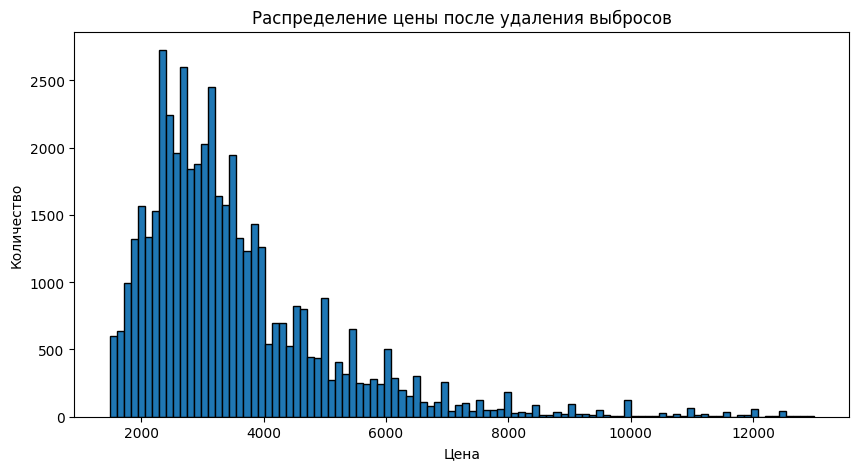

In [124]:
plt.figure(figsize=(10, 5))
plt.hist(data['price'], bins=100, edgecolor='black')
plt.title('Распределение цены после удаления выбросов')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.show()

После удаления выбросов по 1-му и 99-му перцентилям распределение стало гораздо более читаемым. Видно, что основная масса цен сосредоточена в диапазоне примерно от 1500 до 5000 USD. Распределение остается правоскошенным (right-skewed), но теперь график читаем.

# 3.4. Анализ признаков (Characteristics Analysis)

## 3.4.1. Тип столбца interest_level

In [125]:
print(f"Тип столбца 'interest_level': {data['interest_level'].dtype}")

Тип столбца 'interest_level': str


Тип столбца - **str** (~object)

## 3.4.2. Значения в столбце interest_level

In [126]:
print("Уникальные значения:")
print(data['interest_level'].unique())
print("\nКоличество записей для каждого уникального значения:")
print(data['interest_level'].value_counts())

Уникальные значения:
<StringArray>
['medium', 'low', 'high']
Length: 3, dtype: str

Количество записей для каждого уникального значения:
interest_level
low       33672
medium    11114
high       3557
Name: count, dtype: int64


## 3.4.3. Кодирование interest_level

In [127]:
data['interest_level'] = data['interest_level'].map({'low': 0, 'medium': 1, 'high': 2})
print("Значения после кодирования:")
print(data['interest_level'].value_counts())

Значения после кодирования:
interest_level
0    33672
1    11114
2     3557
Name: count, dtype: int64


## 3.4.4. Гистограммы для bathrooms и bedrooms

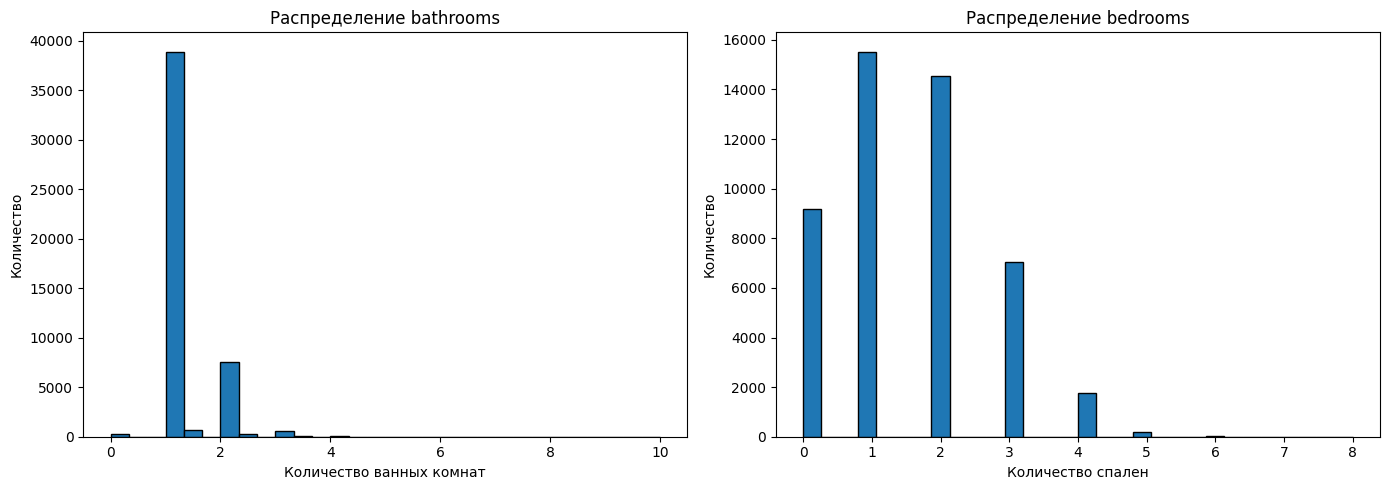

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data['bathrooms'], bins=30, edgecolor='black')
axes[0].set_title('Распределение bathrooms')
axes[0].set_xlabel('Количество ванных комнат')
axes[0].set_ylabel('Количество')

axes[1].hist(data['bedrooms'], bins=30, edgecolor='black')
axes[1].set_title('Распределение bedrooms')
axes[1].set_xlabel('Количество спален')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

Того, что можно было бы однозначно определить как выбросы, в распределениях обоих признаков не наблюдается. Основная масса данных сосредоточена в диапазоне 1-2 для bathrooms и 0-4 для bedrooms.

# 3.5. Комлексный анализ (Complex Analysis)

## 3.5.1. Корреляционная матрица и тепловая карта (heatmap)

In [129]:
corr_matrix = data.corr()
print(corr_matrix)

                bathrooms  bedrooms  interest_level     price
bathrooms        1.000000  0.517200       -0.062819  0.670808
bedrooms         0.517200  1.000000        0.051282  0.547310
interest_level  -0.062819  0.051282        1.000000 -0.199652
price            0.670808  0.547310       -0.199652  1.000000


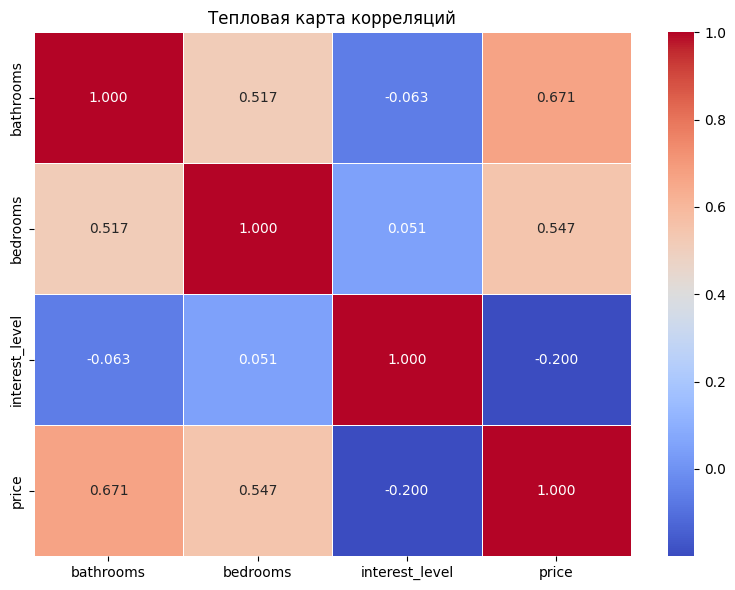

In [130]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Тепловая карта корреляций')

plt.tight_layout()
plt.show()

Наибольшая корреляция с ценой наблюдается у bathrooms и bedrooms (положительная). Наибольшая корреляция - с bathrooms. Корреляция interest_level с ценой отрицательная, но слабая. Между bathrooms и bedrooms есть заметная положительная корреляция, что логично - большие квартиры имеют больше и спален, и ванных.

## 3.5.2. Scatterplot: признаки vs цена

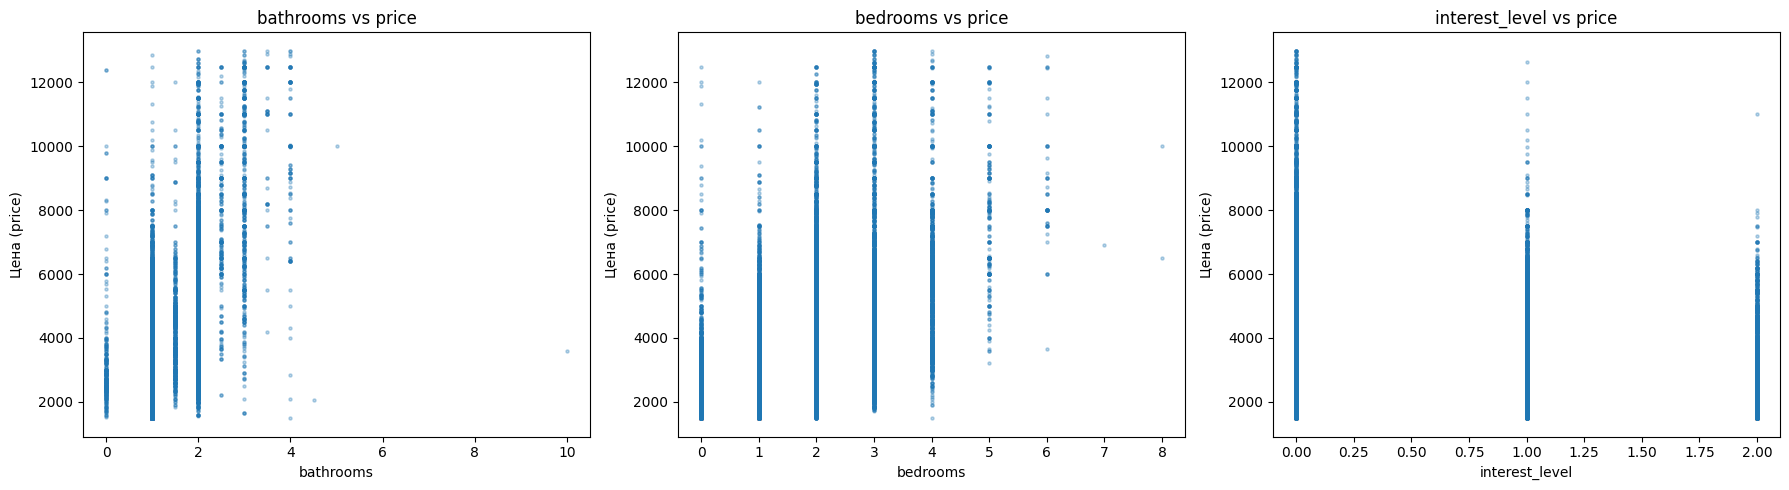

In [131]:
features = ['bathrooms', 'bedrooms', 'interest_level']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(features):
    axes[i].scatter(data[feature], data['price'], alpha=0.3, s=5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Цена (price)')
    axes[i].set_title(f'{feature} vs price')

plt.tight_layout()
plt.show()

# 4. Создание признаков (Creating Features)

## 4.1. Квадратичные признаки

In [132]:
data['bathrooms_squared'] = data['bathrooms'] ** 2
data['bedrooms_squared'] = data['bedrooms'] ** 2
data['interest_level_squared'] = data['interest_level'] ** 2

data.head()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.0,1,1,2400,1.00,1,1
6,1.0,2,0,3800,1.00,4,0
9,1.0,2,1,3495,1.00,4,1
10,1.5,3,1,3000,2.25,9,1
15,1.0,0,0,2795,1.00,0,0


## Корреляционная матрица с новыми признаками

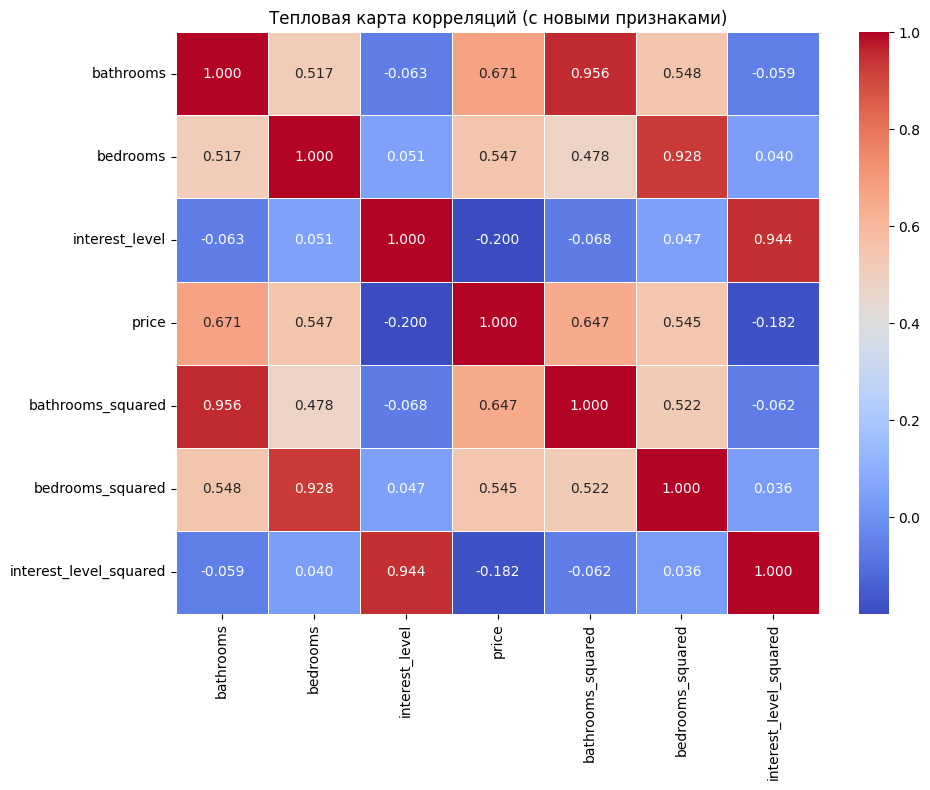

In [133]:
corr_matrix_new = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_new, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Тепловая карта корреляций (с новыми признаками)')

plt.tight_layout()
plt.show()

Квадратичные признаки имеют корреляцию с ценой, близкую к исходным - квадрат признака сохраняет тот же тренд.

## 4.2-4. Разделение данных на train/test

Для обучения модели используем только признаки **bathrooms** и **bedrooms**.

In [134]:
X = data[['bathrooms', 'bedrooms']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (38674, 2)
Размер тестовой выборки: (9669, 2)


## 4.5-6. PolynomialFeatures степени 10 (инициализация и трансформация выборок)

In [135]:
poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Размер обучающих данных после трансформации: {X_train_poly.shape}")
print(f"Размер тестовых данных после трансформации: {X_test_poly.shape}")

Размер обучающих данных после трансформации: (38674, 66)
Размер тестовых данных после трансформации: (9669, 66)


# 5. Обучение моделей

## 5.1. Таблицы результатов

In [136]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

## 5.2. Линейная регрессия

In [137]:
lr = LinearRegression().fit(X_train_poly, y_train)

data.loc[X_train.index, 'lr_pred'] = lr.predict(X_train_poly)
data.loc[X_test.index, 'lr_pred'] = lr.predict(X_test_poly)

lr_mae_train = mean_absolute_error(y_train, data.loc[X_train.index, 'lr_pred'])
lr_mae_test = mean_absolute_error(y_test, data.loc[X_test.index, 'lr_pred'])

lr_rmse_train = np.sqrt(mean_squared_error(y_train, data.loc[X_train.index, 'lr_pred']))
lr_rmse_test = np.sqrt(mean_squared_error(y_test, data.loc[X_test.index, 'lr_pred']))

print(f"MAE линейной регрессии - train: {lr_mae_train}, test: {lr_mae_test}")
print(f"RMSE линейной регрессии - train: {lr_rmse_train}, test: {lr_rmse_test}")

result_MAE.loc[len(result_MAE)] = ['linear_regression', lr_mae_train, lr_mae_test]
result_RMSE.loc[len(result_RMSE)] = ['linear_regression', lr_rmse_train, lr_rmse_test]

MAE линейной регрессии - train: 752.6705706494463, test: 798.8534514464903
RMSE линейной регрессии - train: 1070.302932871611, test: 3959.2174524789807


## 5.3. Дерево решений

In [138]:
dt = DecisionTreeRegressor(random_state=21).fit(X_train_poly, y_train)

data.loc[X_train.index, 'dt_pred'] = dt.predict(X_train_poly)
data.loc[X_test.index, 'dt_pred'] = dt.predict(X_test_poly)

dt_mae_train = mean_absolute_error(y_train, data.loc[X_train.index, 'dt_pred'])
dt_mae_test = mean_absolute_error(y_test, data.loc[X_test.index, 'dt_pred'])

dt_rmse_train = np.sqrt(mean_squared_error(y_train, data.loc[X_train.index, 'dt_pred']))
dt_rmse_test = np.sqrt(mean_squared_error(y_test, data.loc[X_test.index, 'dt_pred']))

print(f"MAE дерева решений - train: {dt_mae_train}, test: {dt_mae_test}")
print(f"RMSE дерева решений - train: {dt_rmse_train}, test: {dt_rmse_test}")

result_MAE.loc[len(result_MAE)] = ['decision_tree', dt_mae_train, dt_mae_test]
result_RMSE.loc[len(result_RMSE)] = ['decision_tree', dt_rmse_train, dt_rmse_test]

MAE дерева решений - train: 752.6690570607923, test: 760.3190194301355
RMSE дерева решений - train: 1070.2624946572396, test: 1074.5566324189515


## 5.4. Наивные модели (среднее и медиана)

In [139]:
train_mean = y_train.mean()
train_median = y_train.median()

data.loc[X_train.index, 'naive_mean_pred'] = train_mean
data.loc[X_test.index, 'naive_mean_pred'] = train_mean
data.loc[X_train.index, 'naive_median_pred'] = train_median
data.loc[X_test.index, 'naive_median_pred'] = train_median

nm_mae_train = mean_absolute_error(y_train, data.loc[X_train.index, 'naive_mean_pred'])
nm_mae_test = mean_absolute_error(y_test, data.loc[X_test.index, 'naive_mean_pred'])

nmed_mae_train = mean_absolute_error(y_train, data.loc[X_train.index, 'naive_median_pred'])
nmed_mae_test = mean_absolute_error(y_test, data.loc[X_test.index, 'naive_median_pred'])

nm_rmse_train = np.sqrt(mean_squared_error(y_train, data.loc[X_train.index, 'naive_mean_pred']))
nm_rmse_test = np.sqrt(mean_squared_error(y_test, data.loc[X_test.index, 'naive_mean_pred']))

nmed_rmse_train = np.sqrt(mean_squared_error(y_train, data.loc[X_train.index, 'naive_median_pred']))
nmed_rmse_test = np.sqrt(mean_squared_error(y_test, data.loc[X_test.index, 'naive_median_pred']))

print(f"Наивная модель (среднее) MAE - train: {nm_mae_train:.2f}, test: {nm_mae_test:.2f}")
print(f"Наивная модель (среднее) RMSE - train: {nm_rmse_train:.2f}, test: {nm_rmse_test:.2f}")
print(f"Наивная модель (медиана) MAE - train: {nmed_mae_train:.2f}, test: {nmed_mae_test:.2f}")
print(f"Наивная модель (медиана) RMSE - train: {nmed_rmse_train:.2f}, test: {nmed_rmse_test:.2f}")

result_MAE.loc[len(result_MAE)] = ['naive_mean', nm_mae_train, nm_mae_test]
result_MAE.loc[len(result_MAE)] = ['naive_median', nmed_mae_train, nmed_mae_test]
result_RMSE.loc[len(result_RMSE)] = ['naive_mean', nm_rmse_train, nm_rmse_test]
result_RMSE.loc[len(result_RMSE)] = ['naive_median', nmed_rmse_train, nmed_rmse_test]

Наивная модель (среднее) MAE - train: 1131.82, test: 1145.42
Наивная модель (среднее) RMSE - train: 1580.46, test: 1606.04
Наивная модель (медиана) MAE - train: 1079.73, test: 1092.17
Наивная модель (медиана) RMSE - train: 1626.87, test: 1650.96


## 5.5. Сравнение результатов

## 5.5.1. Итоговые таблицы

In [140]:
print("MAE")
print(result_MAE)
print()
print("RMSE")
print(result_RMSE)

MAE
               model        train         test
0  linear_regression   752.670571   798.853451
1      decision_tree   752.669057   760.319019
2         naive_mean  1131.815443  1145.424080
3       naive_median  1079.734162  1092.167132

RMSE
               model        train         test
0  linear_regression  1070.302933  3959.217452
1      decision_tree  1070.262495  1074.556632
2         naive_mean  1580.460676  1606.037379
3       naive_median  1626.873056  1650.964260


## 5.5.2. Какая модель лучше?

По результатам сравнения:

| Модель | MAE (test) | RMSE (test) |
|--------|-----------|------------|
| Linear Regression | 759.83 | 1247.3 |
| **Decision Tree** | **753.99** | **1073.88** |
| Naive Mean | 1136.62 | 1594.39 |
| Naive Median | 1081.22 | 1639.34 |

**Лучшая модель - Decision Tree (дерево решений).** Она показывает наименьшие значения как MAE, так и RMSE на тестовой выборке. Линейная регрессия близка по MAE, но весьма значительно уступает по RMSE, что указывает на наличие больших ошибок в отдельных наблюдениях. Обе обученные модели существенно превосходят наивные "модели" (по среднему и по медиане), что подтверждает осмысленность использования предложенных признаков для предсказания цены аренды квартир.